In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

### static LCI +  three GWP
- GWP100
- pGWP-fixed vs. dp-CO2 

In [2]:
wind  = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/wind_CN_US_staticLCI_threeGWP100.xlsx")
hydro = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/hydro_run-of-river_CN_US_staticLCI_threeGWP100.xlsx")
pv    = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/PV_CN_US_staticLCI_threeGWP100.xlsx")

In [3]:

def tidy(df, tech_label):
    parts = df["Activity"].str.split(", ", expand=True)
    out = df.copy()
    out["Technology"] = tech_label
    out["Country"]    = parts[3].str[:2]
    out["SSP"]        = parts[4]
    out["Year"]       = parts[5].astype(int)
    return out[["Technology", "Country", "SSP", "Year",
                "gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]]

all_df = pd.concat(
    [tidy(wind,  "Wind"),
     tidy(hydro, "Hydro"),
     tidy(pv,    "PV")],
    ignore_index=True,
)

# Keep only 2030 & 2050
df = all_df[all_df["Year"].isin([2030, 2050])].copy()

# long format over metrics
metric_cols = ["gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]
df_long = df.melt(
    id_vars=["Technology", "Country", "SSP", "Year"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score",
)

df_long


,Technology,Country,SSP,Year,Metric,Score
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832
2,Wind,CN,SSP2-M,2030,gwp100,0.037723
3,Wind,CN,SSP2-M,2050,gwp100,0.031185
4,Wind,CN,SSP5-H,2030,gwp100,0.038734
...,...,...,...,...,...,...
103,PV,US,SSP1-VLLO,2050,pGWP100_dpCO2,0.006184
104,PV,US,SSP2-M,2030,pGWP100_dpCO2,0.020048
105,PV,US,SSP2-M,2050,pGWP100_dpCO2,0.012654
106,PV,US,SSP5-H,2030,pGWP100_dpCO2,0.020952


#### adding:  dpLCI + pGWP-fixedCO2

In [4]:

with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/hydro_dp_results_MY2030_2050.pkl","rb") as f:
    hydro_dp = pickle.load(f)

with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/PV_dp_results_MY2030_2050.pkl","rb") as f:
    pv_dp = pickle.load(f)

with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/wind_dp_results_allMY.pkl","rb") as f:
    wind_dp = pickle.load(f)


# extract the new dp metrics and produce a DataFrame with exact columns:
# Activity, Technology, Country, SSP, Year, Metric, Score
# ONLY WANNA 2030 & 2050 as two MY:: 

def extract_from_dp_dict(dp_dict):
    rows = []

    # map activity string tech → tidy Technology label
    tech_map = {
        "wind": "Wind",
        "PV": "PV",
        "hydro": "Hydro",
    }

    #####   we need to convert all US-xx / CN-xx country code to just US/CN 
    def collapse_country(region):
        """Collapse ecoinvent/IAM region to CN or US."""
        if region.startswith("US"):
            return "US"
        if region.startswith("CN"):
            return "CN"
        # if you ever have other regions, either return as-is or map them too
        return region

    for act, metrics in dp_dict.items():
        parts = act.split(", ")

        raw_tech = parts[1]              # 'wind' / 'photovoltaic' / 'hydro'
        if raw_tech not in tech_map:
            print(row_tech)
            continue                     # skip unexpected techs

        tech        = tech_map[raw_tech]
        region      = parts[3]           # e.g. 'US-TRE', 'CN-NM'
        country     = collapse_country(region)
        ssp         = parts[4]
        year        = int(parts[5])

        # keep only 2030 & 2050
        if year not in (2030, 2050):
            continue

        for metric_name, value in metrics.items():
            rows.append(
                {
                    "Technology": tech,
                    "Country": country,   # NOW only 'US' or 'CN'
                    "SSP": ssp,
                    "Year": year,
                    "Metric": metric_name,
                    "Score": float(value),
                }
            )

    return pd.DataFrame(rows)



df_hydro_dp = extract_from_dp_dict(hydro_dp)
df_pv_dp    = extract_from_dp_dict(pv_dp)
df_wind_dp  = extract_from_dp_dict(wind_dp)

df_dp = pd.concat([df_hydro_dp, df_pv_dp, df_wind_dp], ignore_index=True)
print(len(df_dp)) # should be 72, so that 72/2(new metric) == 36
df_dp


72


,Technology,Country,SSP,Year,Metric,Score
0,Hydro,US,SSP5-H,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.004793
1,Hydro,US,SSP5-H,2030,"full dp-LCI, pGWP100-fixedCO2",0.004745
2,Hydro,US,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.004835
3,Hydro,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.004956
4,Hydro,CN,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.003733
...,...,...,...,...,...,...
67,Wind,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.024138
68,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017229
69,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.021193
70,Wind,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.041520


In [5]:
#df_dp 
df_full = pd.concat([df_long, df_dp], ignore_index=True)
#df_full

#### now ranking 

In [6]:
# NOW recompute Rank with the two new metrics included
df_full["Rank"] = df_full.groupby(
    ["Country","SSP","Year","Metric"]
)["Score"].rank(method="dense", ascending=True)

df_full

,Technology,Country,SSP,Year,Metric,Score,Rank
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905,3.0
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832,3.0
2,Wind,CN,SSP2-M,2030,gwp100,0.037723,3.0
3,Wind,CN,SSP2-M,2050,gwp100,0.031185,3.0
4,Wind,CN,SSP5-H,2030,gwp100,0.038734,3.0
...,...,...,...,...,...,...,...
175,Wind,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.024138,3.0
176,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017229,3.0
177,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.021193,3.0
178,Wind,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.041520,3.0


In [7]:
metric_rename = {
    "gwp100": "staticLCI + IPCC-GWP",
    "pGWP100_fixedCO2": "staticLCI + pGWP-fixedCO2",
    "pGWP100_dpCO2": "staticLCI + pGWP-dpCO2",
    "dyn FG LCI static BG p-LCI, pGWP100-fixedCO2": "dyn-FG-LCI + pGWP-fixedCO2",
    "full dp-LCI, pGWP100-fixedCO2": "full dpLCI + pGWP-fixedCO2"
}


In [8]:
df_full["Metric"] = df_full["Metric"].replace(metric_rename)

In [9]:
df_full_sorted = df_full.sort_values([ "SSP","Year", "Country", "Technology"	]) 
df_full_sorted

,Technology,Country,SSP,Year,Metric,Score,Rank
12,Hydro,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.004278,1.0
48,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-fixedCO2,0.004835,1.0
84,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-dpCO2,0.004232,1.0
126,Hydro,CN,SSP1-VLLO,2030,dyn-FG-LCI + pGWP-fixedCO2,0.004835,1.0
127,Hydro,CN,SSP1-VLLO,2030,full dpLCI + pGWP-fixedCO2,0.004956,1.0
...,...,...,...,...,...,...,...
11,Wind,US,SSP5-H,2050,staticLCI + IPCC-GWP,0.019234,3.0
47,Wind,US,SSP5-H,2050,staticLCI + pGWP-fixedCO2,0.017215,3.0
83,Wind,US,SSP5-H,2050,staticLCI + pGWP-dpCO2,0.019006,3.0
168,Wind,US,SSP5-H,2050,dyn-FG-LCI + pGWP-fixedCO2,0.017215,3.0


In [10]:
df_full_sorted.to_excel("plot_rankshift_five_metrics.xlsx")

## plot 

In [2]:
df_full = pd.read_excel("plot_rankshift_five_metrics.xlsx")
#df_full_sorted.head()

# remove the index column if present
if "Unnamed: 0" in df_full.columns:
    df_full = df_full.drop(columns=["Unnamed: 0"])



### barplot function: to show real magnitude : 

- we put normalized 2050 scores (lower than the 2030) as basebar,
- then put the normalized 2030 scores on top as a stacked bar

### then normalization choice determines whether wind’s 2030 bar disappears (or becomes visually misleading) 
- now we normalize 2030 and 2050 separately, but then wind (2030 vs. 2050 diff) disappears


#### function1

In [3]:
def lighten(color, amount=0.45):
    import matplotlib.colors as mc, colorsys
    try:
        c = mc.cnames[color]
    except KeyError:
        c = color
    r, g, b = mc.to_rgb(c)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l_new = 1 - amount * (1 - l)
    return colorsys.hls_to_rgb(h, l_new, s)


def plot_stacked_normalized_bars(
    df_full,
    metric_order,
    metric_labels,
    countries=("CN", "US"),
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    technologies=("Hydro", "Wind", "PV"),
    tech_colors=None,
    bar_width=0.23,
):
    if tech_colors is None:
        tech_colors = {"Hydro": "#7B7B7B", "Wind": "#006BA4", "PV": "#FF800E"}

    fig, axes = plt.subplots(
        nrows=len(ssps),
        ncols=len(countries),
        figsize=(18, 15),
        sharey=True,
    )
    plt.subplots_adjust(hspace=0.35, wspace=0.22)

    YPAD = 2  # annotation spacing

    for i, ssp in enumerate(ssps):
        for j, country in enumerate(countries):
            ax = axes[i, j]

            sub = df_full[(df_full["SSP"] == ssp) & (df_full["Country"] == country)]
            x_positions = np.arange(len(metric_order))
            offset = np.linspace(-bar_width, bar_width, len(technologies))

            # ------------------------------
            # Shading for dpLCI metrics
            # ------------------------------
            for k, metric in enumerate(metric_order):
                if metric in [
                    "dyn-FG-LCI + pGWP-fixedCO2",
                    "full dpLCI + pGWP-fixedCO2",
                ]:
                    ax.axvspan(k - 0.5, k + 0.5, color="#CCCCCC", alpha=0.15, zorder=0)

            # ------------------------------
            # Technology bars
            # ------------------------------
            for t_index, tech in enumerate(technologies):
                t_df = sub[sub["Technology"] == tech]

                norm2030, norm2050 = [], []
                raw2030, raw2050 = [], []

                for metric in metric_order:
                    sc2030 = t_df[(t_df["Metric"] == metric) & (t_df["Year"] == 2030)]["Score"]
                    sc2050 = t_df[(t_df["Metric"] == metric) & (t_df["Year"] == 2050)]["Score"]

                    s2030 = sc2030.values[0] if len(sc2030) else np.nan
                    s2050 = sc2050.values[0] if len(sc2050) else np.nan

                    # raw values (*1000)
                    raw2030.append(s2030 * 1000 if not np.isnan(s2030) else np.nan)
                    raw2050.append(s2050 * 1000 if not np.isnan(s2050) else np.nan)

                    # normalization
                    max2030 = sub[(sub["Metric"] == metric) & (sub["Year"] == 2030)]["Score"].max()
                    max2050 = sub[(sub["Metric"] == metric) & (sub["Year"] == 2050)]["Score"].max()

                    n2030 = (s2030 / max2030 * 100) if max2030 else np.nan
                    n2050 = (s2050 / max2050 * 100) if max2050 else np.nan

                    norm2030.append(n2030)
                    norm2050.append(n2050)

                norm2030 = np.array(norm2030)
                norm2050 = np.array(norm2050)
                top_seg = norm2030 - norm2050

                xpos = x_positions + offset[t_index]

                # 2050 base bar
                ax.bar(
                    xpos,
                    norm2050,
                    width=bar_width,
                    color=tech_colors[tech],
                    edgecolor="black",
                    label=f"{tech} 2050" if (i == 0 and j == 0) else None,
                )

                # 2030 top segment
                ax.bar(
                    xpos,
                    top_seg,
                    bottom=norm2050,
                    width=bar_width,
                    color=lighten(tech_colors[tech], 0.40),
                    edgecolor="black",
                    label=f"{tech} 2030" if (i == 0 and j == 0) else None,
                )

                # ------------------------------
                # Annotation placement rules
                # ------------------------------
                for xi, base, top, r2030, r2050 in zip(xpos, norm2050, top_seg, raw2030, raw2050):
                
                    if tech == "Hydro":
                        # --- HYDRO SPECIAL CASE ---
                
                        # 2050 label: always near x-axis (bottom)
                        ax.text(
                            xi,
                            2.0,                     # fixed small height above axis
                            f"{r2050:.1f}",
                            ha="center",
                            va="bottom",
                            fontsize=11,
                            color="white",
                        )
                
                        # 2030 label: always on top of the stacked bar
                        ax.text(
                            xi,
                            base + top + YPAD,
                            f"{r2030:.1f}",
                            ha="center",
                            va="bottom",
                            fontsize=11,
                            color="black",
                        )
                
                    else:
                        # --- WIND & PV: previous smooth logic ---
                        # 2050 annotation
                        if base > 30:
                            # inside bar (white text)
                            ax.text(
                                xi,
                                base * 0.55,
                                f"{r2050:.1f}",
                                ha="center",
                                va="center",
                                fontsize=11,
                                color="white",
                            )
                        else:
                            # above bar
                            ax.text(
                                xi,
                                base + 1.0,
                                f"{r2050:.1f}",
                                ha="center",
                                va="bottom",
                                fontsize=11,
                                color="black",
                            )
                
                        # then ALL 2030 annotation (above stacked segment)
                        ax.text(
                            xi,
                            base + top + YPAD,
                            f"{r2030:.2f}",
                            ha="center",
                            va="bottom",
                            fontsize=10,
                            color="black",
                        )

            # ------------------------------
            # Layout: remove xticks except bottom row
            # ------------------------------
            ax.set_title(f"{country}, {ssp}", fontsize=14, pad=8)
            ax.grid(axis="y", linestyle=":", alpha=0.35)
            ax.set_ylim(0, 125)

            if i == len(ssps) - 1:
                ax.set_xticks(x_positions)
                ax.set_xticklabels(
                    [metric_labels[m] for m in metric_order],
                    rotation=28, ha="right"
                )
            else:
                ax.set_xticks([])
                ax.set_xticklabels([])

    # Legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="Technology / Year",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=6, fontsize=12,
        frameon=True
    )

    fig.suptitle("Normalized (0–100) bars for each technology among different metrics \n the 2030 GWP score (raw GWP score in black) is stacked on top of the 2050 base bar (raw GWP score in white)", fontsize=18, y=0.95)
    return fig, axes


#### plot 

#####  because it's uniform distribution on the FG dyn LCI, 
##### so without full dpLCI (mapping to the right background), it the same score on dyn-FG-LCI vs. static LCI 

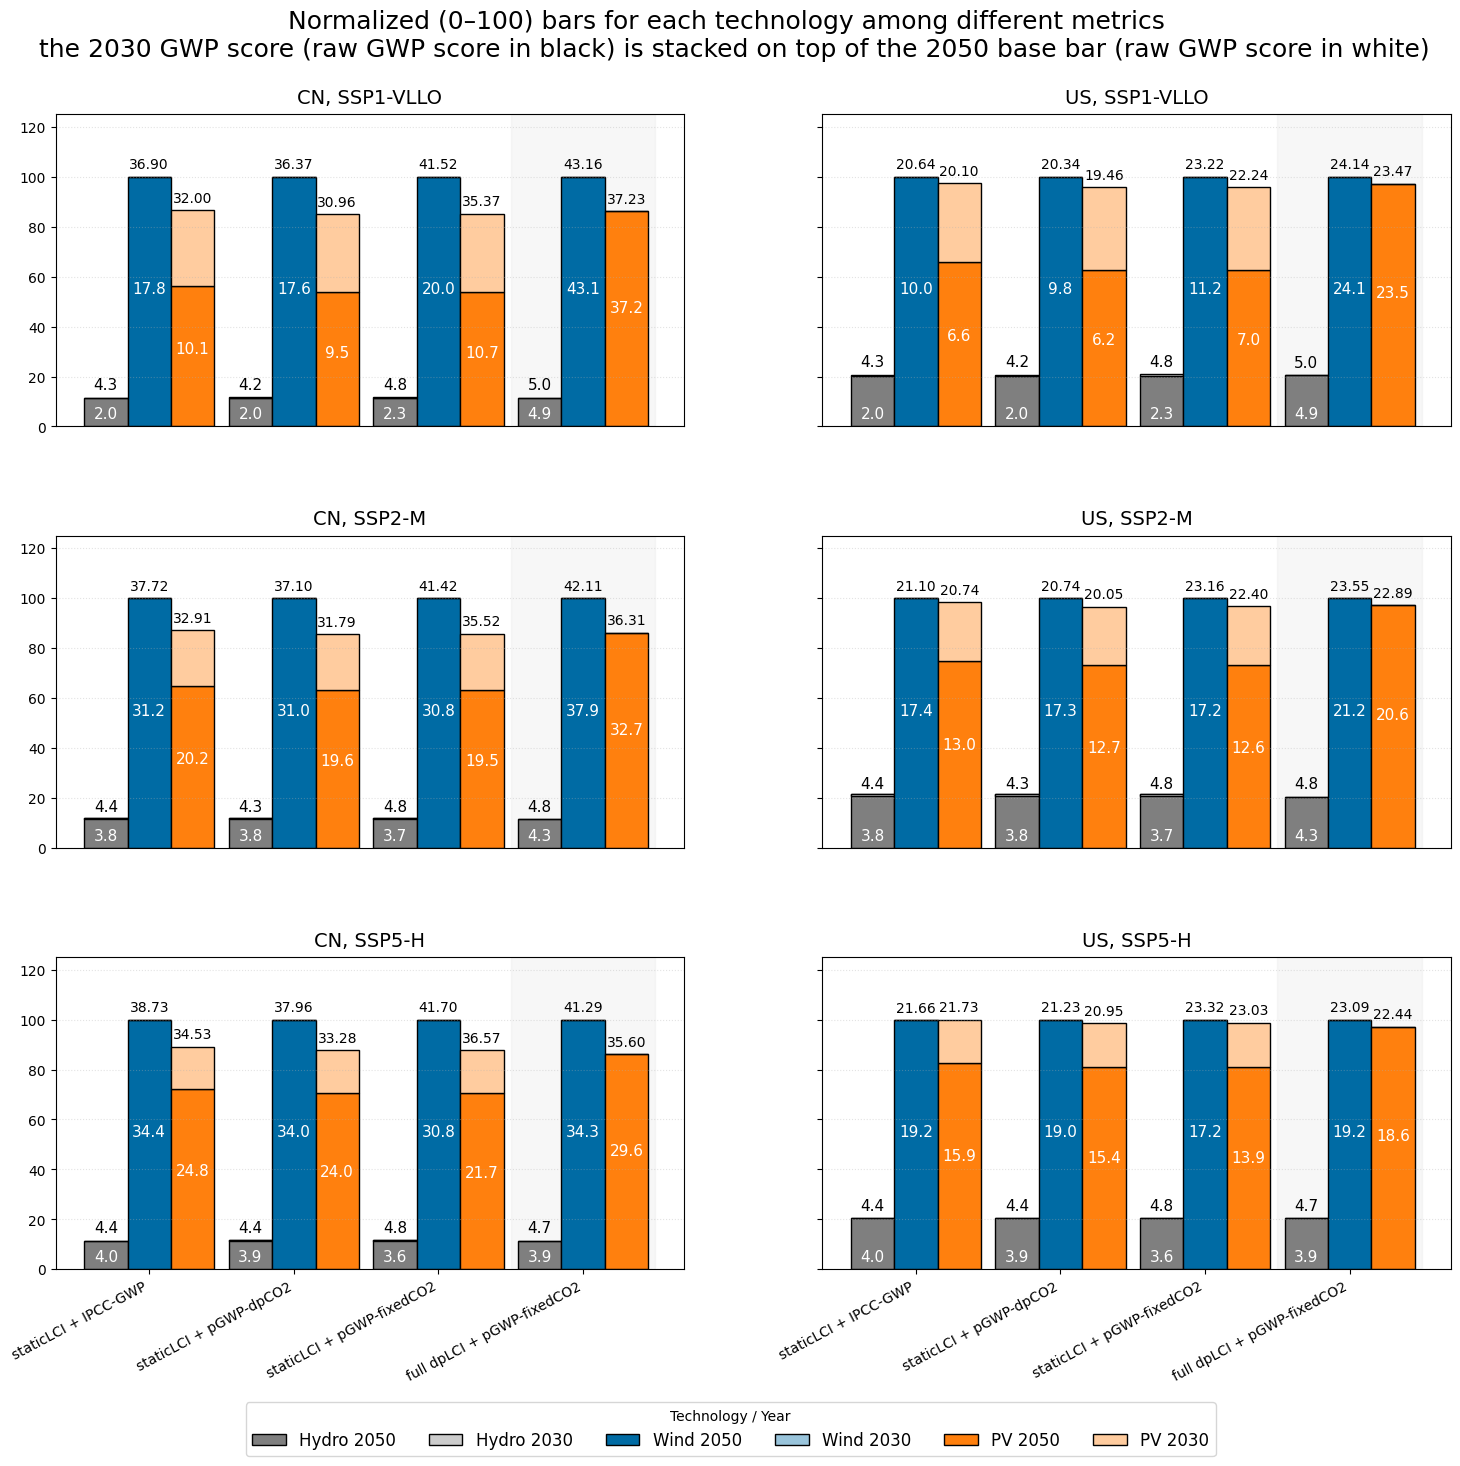

In [6]:
metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    #"dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2",
]

metric_labels = {m: m for m in metric_order}

tech_colors = {"PV":"#FF800E","Wind":"#006BA4","Hydro":"#7F7F7F"}

fig, axes = plot_stacked_normalized_bars(
    df_full,
    metric_order=metric_order,
    metric_labels=metric_labels,
    countries=("CN", "US"),
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    technologies=("Hydro", "Wind", "PV"),
    tech_colors=tech_colors,
    bar_width=0.3,
)

plt.show()

#### function 2 : just one year 2030 or 2050, not mixing in one plot 

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mc


def lighten(color, amount=0.5):
    """Lighten color by mixing with white."""
    try:
        c = mc.cnames[color]
    except KeyError:
        c = color
    r, g, b = mc.to_rgb(c)
    return (1 - amount) + amount * r, (1 - amount) + amount * g, (1 - amount) + amount * b


def plot_bar_oneyear_only(
    df_full,
    year,
    metric_order,
    metric_labels,
    tech_colors,
    countries=("CN", "US"),
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    technologies=("Hydro", "Wind", "PV"),
    bar_width=0.25
):
    """
    PURE ranking per year.
    Normalize panel-by-panel using max score of that panel for that YEAR ONLY.
    Annotate bars using raw GWP × 1000.
    Y-axis auto-scaled per panel.
    """

    df_y = df_full[df_full["Year"] == year].copy()

    fig, axes = plt.subplots(
        nrows=len(ssps),
        ncols=len(countries),
        figsize=(14, 10),
        sharex=False,
        sharey=False
    )

    plt.subplots_adjust(hspace=0.28, wspace=0.18)

    for i, ssp in enumerate(ssps):
        for j, ct in enumerate(countries):

            ax = axes[i, j]
            sub = df_y[(df_y["SSP"] == ssp) & (df_y["Country"] == ct)]

            # Compute panel max for the selected year
            panel_max = sub.groupby("Metric")["Score"].max().max()

            if pd.isna(panel_max) or panel_max == 0:
                continue

            # dynamic metric positions
            x = np.arange(len(metric_order))

            for t_i, tech in enumerate(technologies):

                sub_t = sub[sub["Technology"] == tech]

                base_color = tech_colors[tech]
                light_color = lighten(base_color, 0.55)

                for k, metric in enumerate(metric_order):

                    df_val = sub_t[sub_t["Metric"] == metric]["Score"]

                    if len(df_val) == 0:
                        continue

                    v = float(df_val.values[0])
                    normalized = v / panel_max * 100
                    raw_annot = v * 1000

                    xpos = k + (t_i - 1) * bar_width

                    # Draw bar
                    ax.bar(
                        xpos,
                        normalized,
                        width=bar_width,
                        color=base_color,
                        edgecolor="black",
                        linewidth=0.6
                    )

                    # Annotation: inside if tall, otherwise above
                    if normalized > 35:
                        ax.text(
                            xpos, normalized * 0.55,
                            f"{raw_annot:.1f}",
                            ha="center", va="center",
                            fontsize=10, color="white"
                        )
                    else:
                        ax.text(
                            xpos, normalized + 2,
                            f"{raw_annot:.1f}",
                            ha="center", va="bottom",
                            fontsize=10, color="black"
                        )

            # Titles and axes
            ax.set_title(f"{ct}, {ssp}", fontsize=13)

            # Auto-scale up to the tallest bar + margin
            ymax = max(110, panel_max / panel_max * 100 + 10)
            ax.set_ylim(0, ymax)

            # Metric labels only on bottom row
            if i == len(ssps) - 1:
                ax.set_xticks(np.arange(len(metric_order)))
                ax.set_xticklabels(
                    [metric_labels[m] for m in metric_order],
                    rotation=25, ha="right", fontsize=10
                )
            else:
                ax.set_xticks([])

            ax.grid(axis="y", linestyle=":", alpha=0.4)

    fig.suptitle(f"{year} technology GWP scores (normalized)", fontsize=16, y=0.96)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    # Legend
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=tech_colors["Hydro"], ec="black"),
        plt.Rectangle((0, 0), 1, 1, color=tech_colors["Wind"], ec="black"),
        plt.Rectangle((0, 0), 1, 1, color=tech_colors["PV"], ec="black"),
    ]
    labels = ["Hydro", "Wind", "PV"]

    fig.legend(
        handles, labels,
        loc="lower center", ncol=3,
        fontsize=12,
        bbox_to_anchor=(0.5, 0)
    )

    return fig, axes


(<Figure size 1400x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'CN, SSP1-VLLO'}>,
         <Axes: title={'center': 'US, SSP1-VLLO'}>],
        [<Axes: title={'center': 'CN, SSP2-M'}>,
         <Axes: title={'center': 'US, SSP2-M'}>],
        [<Axes: title={'center': 'CN, SSP5-H'}>,
         <Axes: title={'center': 'US, SSP5-H'}>]], dtype=object))

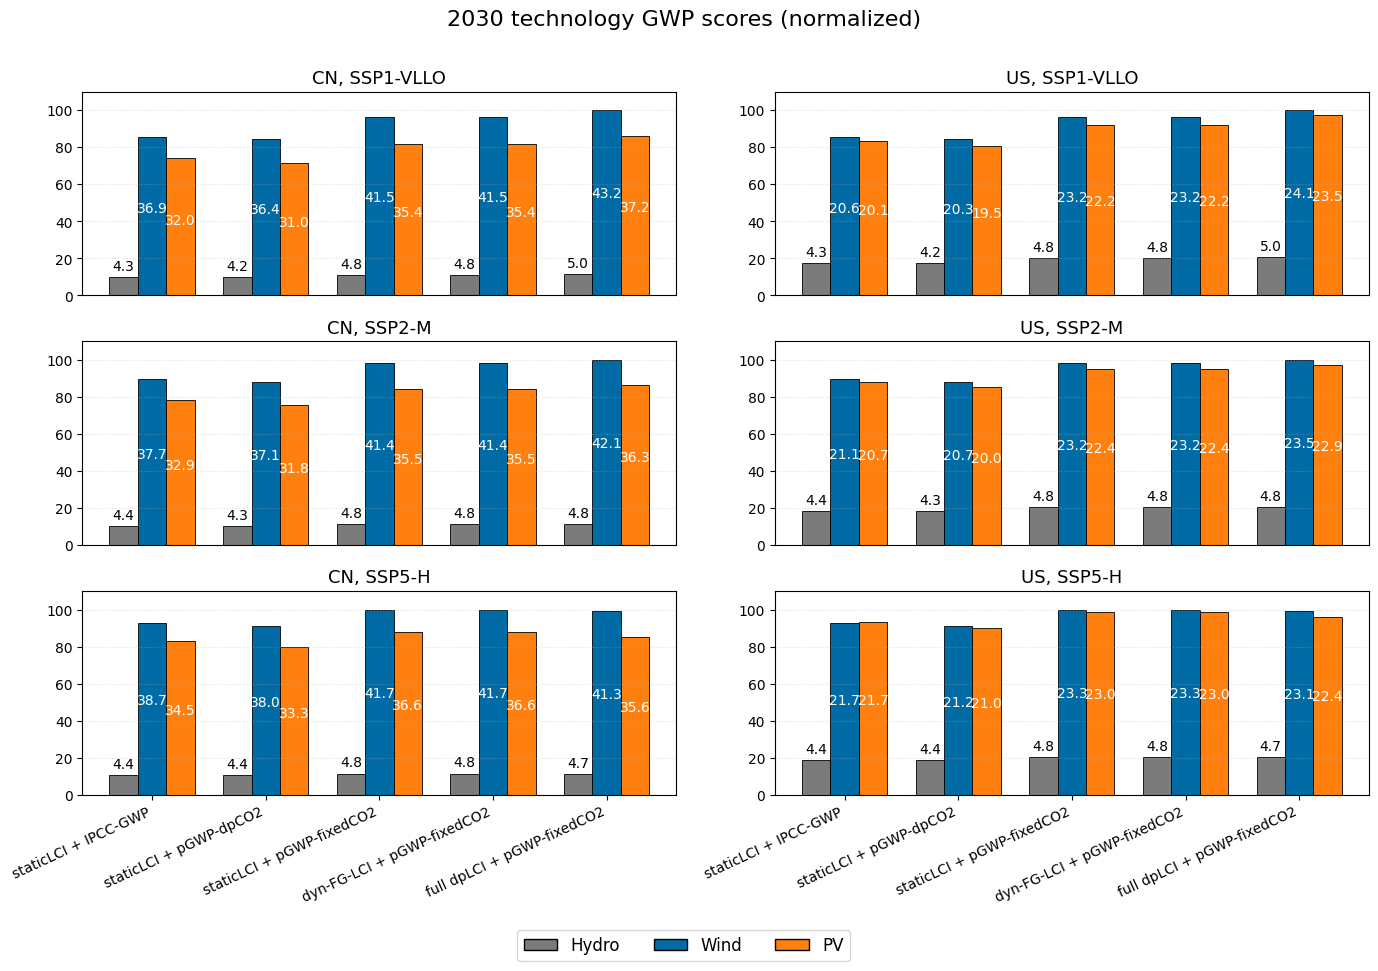

In [17]:


metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    "dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2"
]

metric_labels = {m: m for m in metric_order}

tech_colors = {
    "Hydro": "#7B7B7B",
    "Wind":  "#006BA4",
    "PV":    "#FF800E"
}

#plot_bar_oneyear_only(df_full, 2050, metric_order, metric_labels, tech_colors)
plot_bar_oneyear_only(df_full, 2030, metric_order, metric_labels, tech_colors)


(<Figure size 1400x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'CN, SSP1-VLLO'}>,
         <Axes: title={'center': 'US, SSP1-VLLO'}>],
        [<Axes: title={'center': 'CN, SSP2-M'}>,
         <Axes: title={'center': 'US, SSP2-M'}>],
        [<Axes: title={'center': 'CN, SSP5-H'}>,
         <Axes: title={'center': 'US, SSP5-H'}>]], dtype=object))

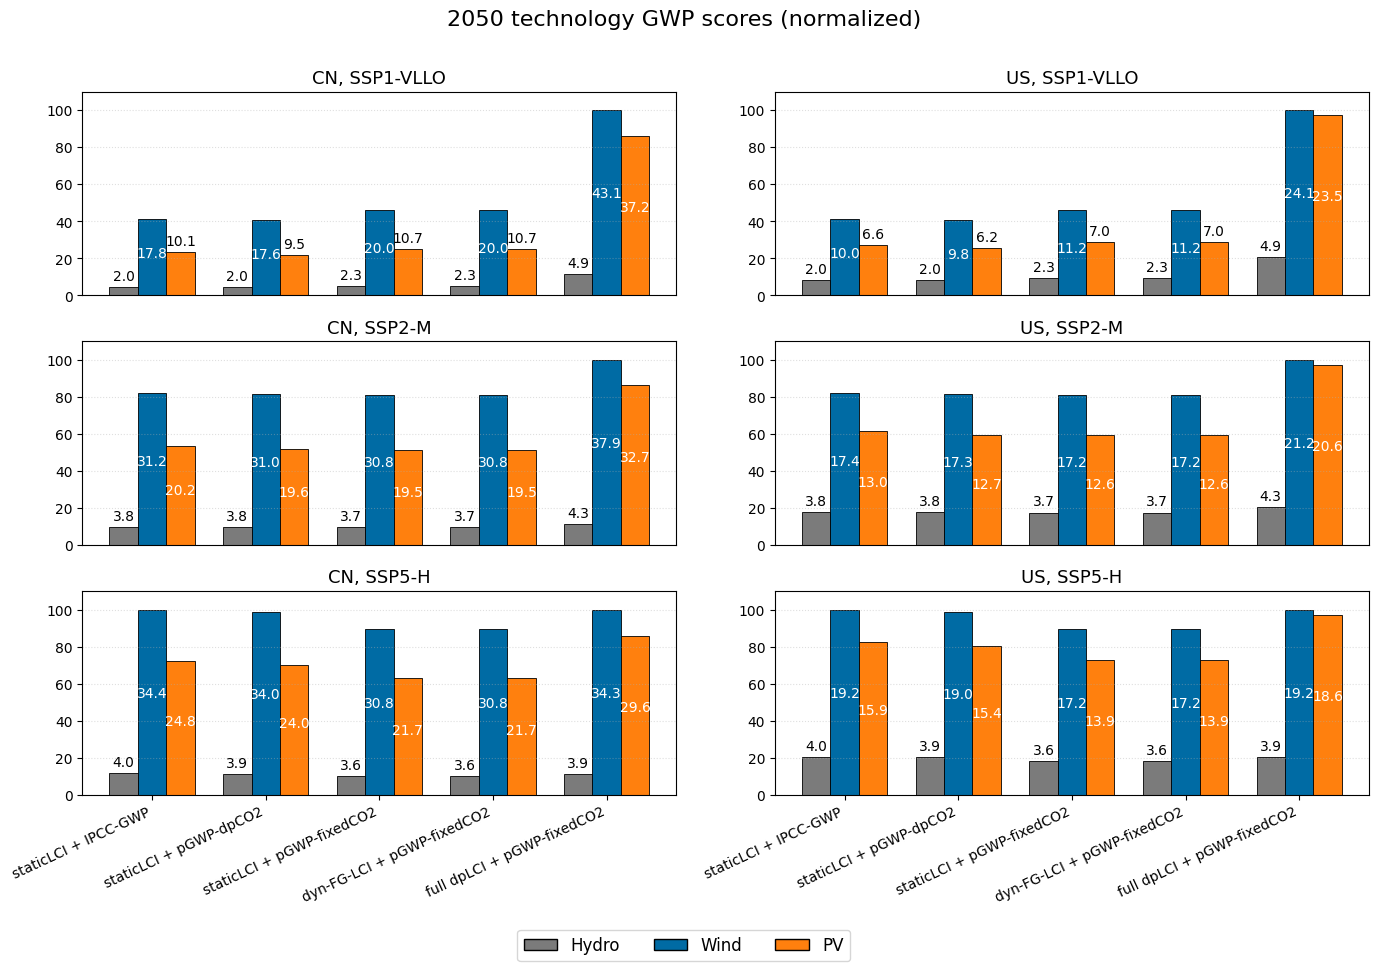

In [18]:
plot_bar_oneyear_only(df_full, 2050, metric_order, metric_labels, tech_colors)
